In [1]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt

In [2]:

data_raw_path = 'training_set_VU_DM.csv'
data = pd.read_csv(data_raw_path)

print(f"Shape: {data.shape}")
print(f"Types: {data.dtypes}")

Shape: (4958347, 54)
Types: srch_id                          int64
date_time                       object
site_id                          int64
visitor_location_country_id      int64
visitor_hist_starrating        float64
visitor_hist_adr_usd           float64
prop_country_id                  int64
prop_id                          int64
prop_starrating                  int64
prop_review_score              float64
prop_brand_bool                  int64
prop_location_score1           float64
prop_location_score2           float64
prop_log_historical_price      float64
position                         int64
price_usd                      float64
promotion_flag                   int64
srch_destination_id              int64
srch_length_of_stay              int64
srch_booking_window              int64
srch_adults_count                int64
srch_children_count              int64
srch_room_count                  int64
srch_saturday_night_bool         int64
srch_query_affinity_score      float

In [3]:
data.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [4]:
missing_counts = data.isna().sum()
missing_percent = (data.isna().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print(missing_summary)

                             Missing Count  Missing %
comp1_rate_percent_diff            4863908  98.095353
comp6_rate_percent_diff            4862173  98.060362
comp1_rate                         4838417  97.581250
comp1_inv                          4828788  97.387053
comp4_rate_percent_diff            4827261  97.356256
gross_bookings_usd                 4819957  97.208949
comp7_rate_percent_diff            4819832  97.206428
comp6_rate                         4718190  95.156511
visitor_hist_starrating            4706481  94.920364
visitor_hist_adr_usd               4705359  94.897735
comp6_inv                          4697371  94.736633
comp4_rate                         4650969  93.800797
comp7_rate                         4642999  93.640058
srch_query_affinity_score          4640941  93.598552
comp4_inv                          4614684  93.069001
comp7_inv                          4601925  92.811677
comp3_rate_percent_diff            4485550  90.464625
comp2_rate_percent_diff     

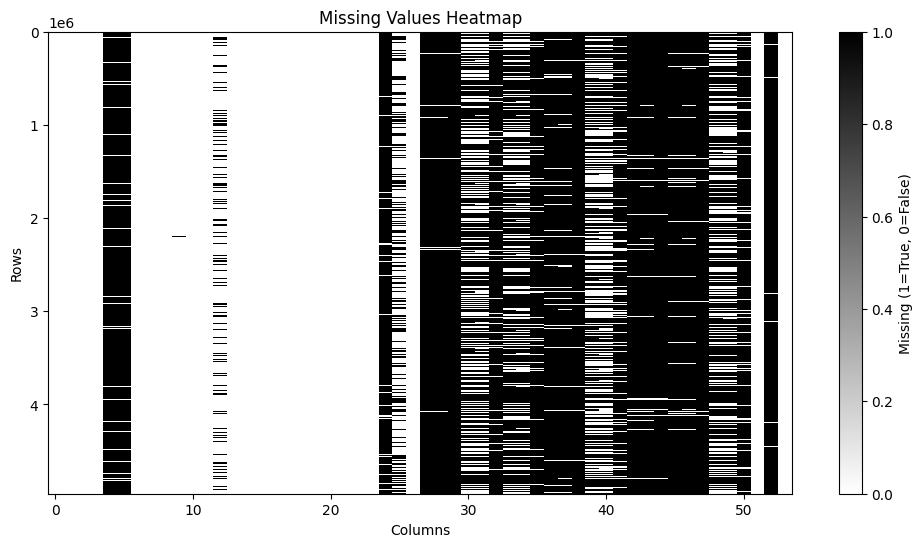

In [5]:
plt.figure(figsize=(12, 6))
plt.imshow(data.isnull(), aspect='auto', cmap='gray_r', interpolation='none')
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.title("Missing Values Heatmap")
plt.colorbar(label='Missing (1=True, 0=False)')
plt.show()

In [8]:
unique_counts = data.nunique().sort_values()
print(unique_counts)  # Least unique values

random_bool                         2
click_bool                          2
srch_saturday_night_bool            2
promotion_flag                      2
prop_brand_bool                     2
booking_bool                        2
comp7_inv                           3
comp5_inv                           3
comp5_rate                          3
comp4_inv                           3
comp4_rate                          3
comp3_inv                           3
comp3_rate                          3
comp2_inv                           3
comp2_rate                          3
comp6_inv                           3
comp1_inv                           3
comp1_rate                          3
comp7_rate                          3
comp6_rate                          3
comp8_inv                           3
comp8_rate                          3
prop_starrating                     6
srch_room_count                     8
srch_adults_count                   9
srch_children_count                10
prop_review_

In [11]:
print(f"Duplicate rows: {data.duplicated().sum()}")

Duplicate rows: 0


In [10]:
print(data.describe(include='all').transpose())

                                 count  unique                  top freq  \
srch_id                      4958347.0     NaN                  NaN  NaN   
date_time                      4958347  198615  2012-11-02 14:04:51   95   
site_id                      4958347.0     NaN                  NaN  NaN   
visitor_location_country_id  4958347.0     NaN                  NaN  NaN   
visitor_hist_starrating       251866.0     NaN                  NaN  NaN   
visitor_hist_adr_usd          252988.0     NaN                  NaN  NaN   
prop_country_id              4958347.0     NaN                  NaN  NaN   
prop_id                      4958347.0     NaN                  NaN  NaN   
prop_starrating              4958347.0     NaN                  NaN  NaN   
prop_review_score            4950983.0     NaN                  NaN  NaN   
prop_brand_bool              4958347.0     NaN                  NaN  NaN   
prop_location_score1         4958347.0     NaN                  NaN  NaN   
prop_locatio

In [14]:
# Step 1: Create `dates_df` with only date_time and booking_bool
dates_df = data[['date_time', 'booking_bool']].copy()

# Step 2: Convert date_time to datetime if not already
dates_df['date_time'] = pd.to_datetime(dates_df['date_time'], errors='coerce')

# Step 3: Extract date, time, day of week
dates_df['date'] = dates_df['date_time'].dt.date
dates_df['time'] = dates_df['date_time'].dt.time
dates_df['hour'] = dates_df['date_time'].dt.hour
dates_df['month'] = dates_df['date_time'].dt.month_name()
dates_df['day_of_week'] = dates_df['date_time'].dt.day_name()
dates_df['is_weekend'] = dates_df['date_time'].dt.dayofweek.isin([5, 6])

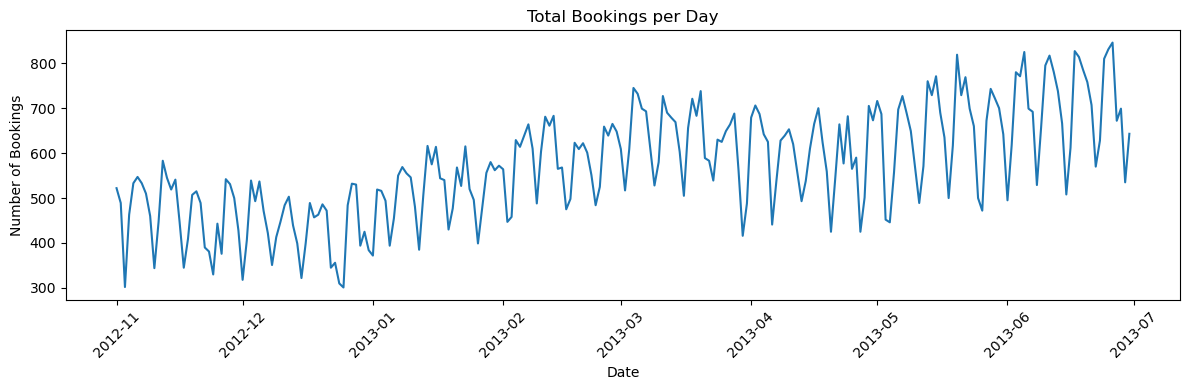

In [8]:
daily = dates_df.groupby('date')['booking_bool'].sum()

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily.values)
plt.title("Total Bookings per Day")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
dates_df['month'] = dates_df['date_time'].dt.month_name()

monthly_counts = dates_df.groupby('month')['booking_bool'].sum()
# Reorder months for proper display
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_counts = monthly_counts.reindex(month_order)

plt.figure(figsize=(10, 4))
plt.bar(monthly_counts.index, monthly_counts.values)
plt.title("Total Bookings by Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

In [12]:
dates_df['year_month'] = dates_df['date_time'].dt.to_period('M').astype(str)

monthly_counts = dates_df.groupby('year_month')['booking_bool'].sum()

plt.figure(figsize=(12, 4))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.title("Total Bookings by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

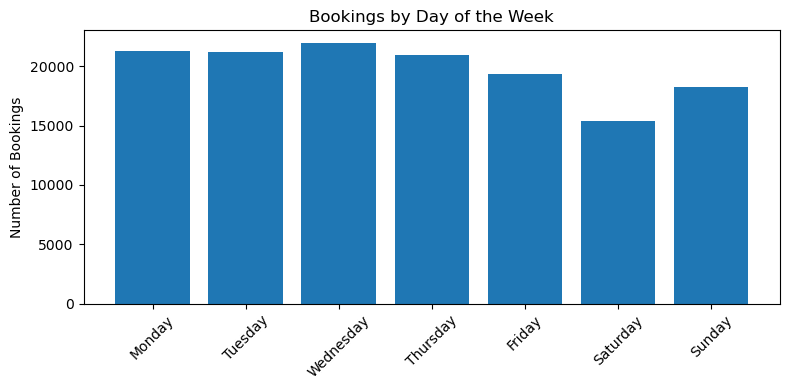

In [12]:
weekday = dates_df.groupby('day_of_week')['booking_bool'].sum()
# Optional: reorder to logical weekday order
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday = weekday.reindex(ordered_days)

plt.figure(figsize=(8, 4))
plt.bar(weekday.index, weekday.values)
plt.title("Bookings by Day of the Week")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
hourly = dates_df.groupby('hour')['booking_bool'].sum()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values)
plt.title("Bookings by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Bookings")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

In [10]:
daily_rates = dates_df.groupby('date')['booking_bool'].mean() * 100

plt.figure(figsize=(12, 4))
plt.plot(daily_rates.index, daily_rates.values)
plt.title("Daily Booking Rate (%)")
plt.xlabel("Date")
plt.ylabel("Booking Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

In [9]:
weekday_rates = dates_df.groupby('day_of_week')['booking_bool'].mean() * 100
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_rates = weekday_rates.reindex(weekday_order)

plt.figure(figsize=(8, 4))
plt.bar(weekday_rates.index, weekday_rates.values)
plt.title("Booking Rate by Day of the Week (%)")
plt.ylabel("Booking Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

In [8]:
hourly_rates = dates_df.groupby('hour')['booking_bool'].mean() * 100

plt.figure(figsize=(10, 4))
plt.bar(hourly_rates.index, hourly_rates.values)
plt.title("Booking Rate by Hour of Day (%)")
plt.xlabel("Hour")
plt.ylabel("Booking Rate (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

NameError: name 'dates_df' is not defined

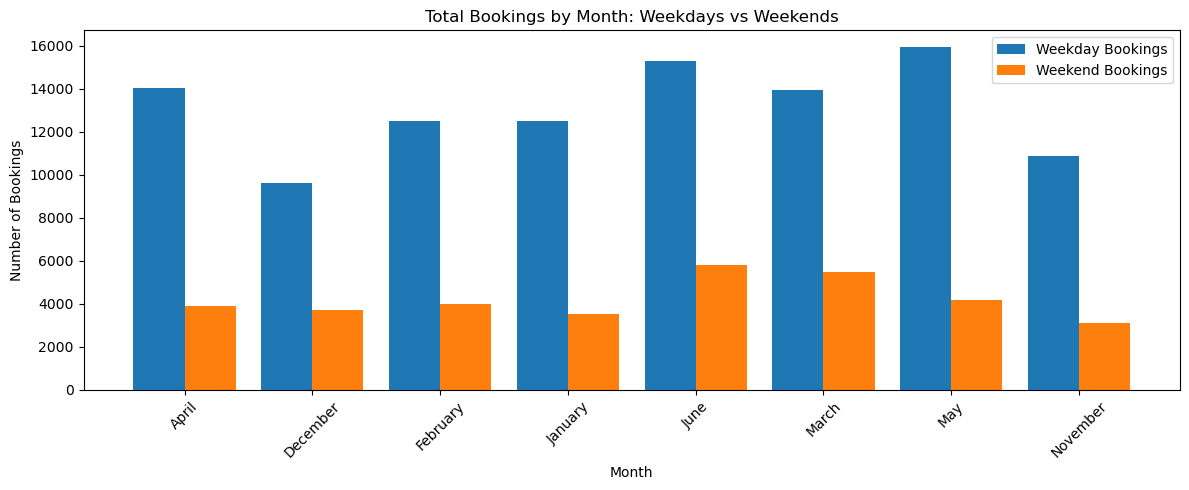

In [15]:
grouped = dates_df.groupby(['month', 'is_weekend'])['booking_bool'].sum().unstack(fill_value=0)
grouped.columns = ['Weekday Bookings', 'Weekend Bookings']  # False → Weekday, True → Weekend

months = grouped.index
x = np.arange(len(months))
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, grouped['Weekday Bookings'], width=width, label='Weekday Bookings')
plt.bar(x + width/2, grouped['Weekend Bookings'], width=width, label='Weekend Bookings')

plt.title("Total Bookings by Month: Weekdays vs Weekends")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(ticks=x, labels=months, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

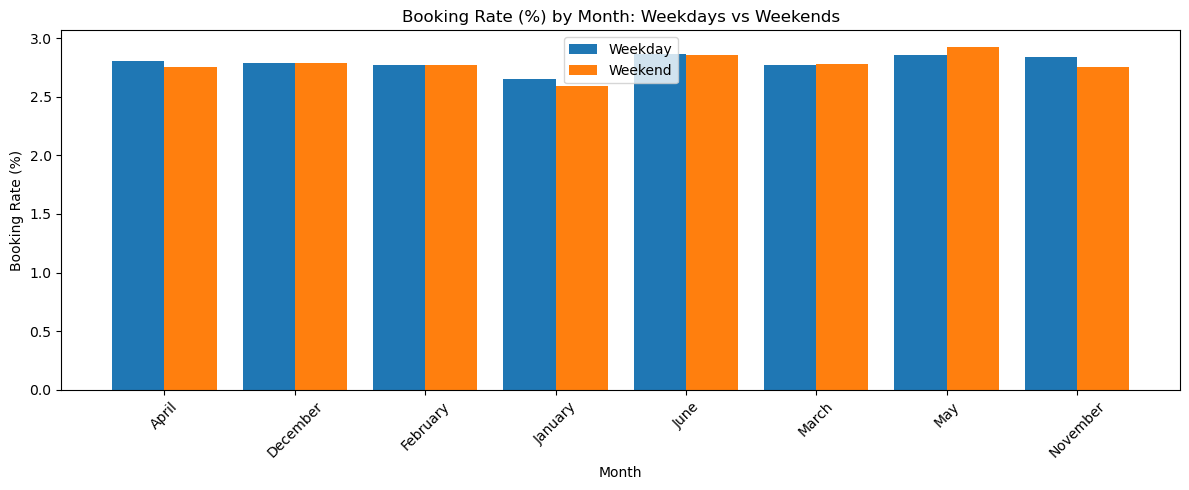

In [16]:
# Group by month and is_weekend
counts = dates_df.groupby(['month', 'is_weekend'])['booking_bool'].agg(['sum', 'count'])
counts = counts.rename(columns={'sum': 'bookings', 'count': 'total_searches'})
counts['booking_rate'] = counts['bookings'] / counts['total_searches'] * 100

# Pivot for plotting
booking_rate_pivot = counts['booking_rate'].unstack().fillna(0)
booking_rate_pivot.columns = ['Weekday %', 'Weekend %']  # False = weekday, True = weekend

months = booking_rate_pivot.index
x = np.arange(len(months))
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, booking_rate_pivot['Weekday %'], width=width, label='Weekday')
plt.bar(x + width/2, booking_rate_pivot['Weekend %'], width=width, label='Weekend')

plt.title("Booking Rate (%) by Month: Weekdays vs Weekends")
plt.xlabel("Month")
plt.ylabel("Booking Rate (%)")
plt.xticks(ticks=x, labels=months, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
df = data.copy()
# Define column groups
rate_cols = [f'comp{i}_rate' for i in range(1, 9)]
inv_cols = [f'comp{i}_inv' for i in range(1, 9)]
diff_cols = [f'comp{i}_rate_percent_diff' for i in range(1, 9)]

# Compute row-wise means, ignoring NaNs
df['comp_rate_mean'] = df[rate_cols].sum(axis=1)
df['comp_inv_mean'] = df[inv_cols].sum(axis=1)
df['comp_rate_percent_diff_mean'] = df[diff_cols].mean(axis=1)
df['comp_rate_std'] = df[rate_cols].std(axis=1)
df['comp_rate_count'] = df[rate_cols].notna().sum(axis=1)

df.drop(columns=rate_cols + inv_cols + diff_cols, inplace=True)

# Calculate % of NaNs in the new aggregated columns
agg_cols = [
    'comp_rate_mean',
    'comp_inv_mean',
    'comp_rate_percent_diff_mean',
    'comp_rate_std',
    'comp_rate_count']
nan_percentages = df[agg_cols].isna().mean() * 100

print(nan_percentages)

comp_rate_mean                  0.000000
comp_inv_mean                   0.000000
comp_rate_percent_diff_mean    68.124659
comp_rate_std                  46.080055
comp_rate_count                 0.000000
dtype: float64


In [18]:
group_cols = [
    'visitor_location_country_id',
    'srch_destination_id',
    'srch_length_of_stay',
    'srch_adults_count',
    'srch_children_count'
]

# Step 1: Group medians for both columns
group_medians = (
    df.groupby(group_cols)[['visitor_hist_adr_usd', 'visitor_hist_starrating']]
    .median()
    .reset_index()
    .rename(columns={
        'visitor_hist_adr_usd': 'group_median_adr',
        'visitor_hist_starrating': 'group_median_starrating'
    })
)

# Step 2: Merge group medians back into df
df = df.merge(group_medians, on=group_cols, how='left')

# Step 3: Impute from group values
df['visitor_hist_adr_usd'] = df['visitor_hist_adr_usd'].fillna(df['group_median_adr'])
df['visitor_hist_starrating'] = df['visitor_hist_starrating'].fillna(df['group_median_starrating'])

# Step 4: Fallback to global medians if still NaN
df['visitor_hist_adr_usd'] = df['visitor_hist_adr_usd'].fillna(df['visitor_hist_adr_usd'].median())
df['visitor_hist_starrating'] = df['visitor_hist_starrating'].fillna(df['visitor_hist_starrating'].median())

# Step 5: Clean up
df = df.drop(columns=['group_median_adr', 'group_median_starrating'])

In [19]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print(missing_summary)

                             Missing Count  Missing %
gross_bookings_usd                 4819957  97.208949
srch_query_affinity_score          4640941  93.598552
comp_rate_percent_diff_mean        3377857  68.124659
comp_rate_std                      2284809  46.080055
orig_destination_distance          1607782  32.425766
prop_location_score2               1090348  21.990151
prop_review_score                     7364   0.148517
srch_children_count                      0   0.000000
srch_room_count                          0   0.000000
srch_saturday_night_bool                 0   0.000000
srch_id                                  0   0.000000
random_bool                              0   0.000000
srch_booking_window                      0   0.000000
click_bool                               0   0.000000
booking_bool                             0   0.000000
comp_rate_mean                           0   0.000000
comp_inv_mean                            0   0.000000
srch_adults_count           

In [20]:
date_time_saver = df['date_time']
df = df.drop(columns= ['gross_bookings_usd','date_time'])

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

target_columns = [
    'srch_query_affinity_score',
    'comp_rate_percent_diff_mean',
    'comp_rate_std',
    'orig_destination_distance',
    'prop_location_score2',
    'prop_review_score'
]

# Prepare function for cleaning and imputing NaN values
def prepare_df(df, target_column):
    target_values = df[target_column].values
    df_cleaned = df.dropna(axis=1, how='any')  # Drop columns with any NaN values
    df_cleaned[target_column] = target_values  # Re-add the target column
    return df_cleaned

# Iterate through each column with missing values
for target_column in target_columns:
    df_train_iter = prepare_df(df, target_column)

    # Prepare the features (X) and target (y) for the regression model
    X = df_train_iter.copy().drop(columns=[target_column])  # Features (excluding target)
    y = df_train_iter[target_column]  # Target column

    # Separate rows with missing values in the target column for prediction
    X_missing = X[df_train_iter[target_column].isnull()]
    X_train = X[df_train_iter[target_column].notnull()]
    y_train = y[df_train_iter[target_column].notnull()]

    # Initialize and fit the regression model
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)

    # Predict the missing values
    predicted_values = regressor.predict(X_missing)

    # Ensure that the length of predictions matches the number of missing values
    if len(predicted_values) == len(X_missing):
        # Create a pandas Series with the predicted values and align with the indices of the missing values
        predicted_series = pd.Series(predicted_values, index=df.loc[df[target_column].isnull()].index)

        # Assign predictions back to the DataFrame
        df.loc[df[target_column].isnull(), target_column] = predicted_series

        # Optional: Check if there are still missing values in the target column
        print(f"Missing values after imputation for {target_column}: {df[target_column].isnull().sum()}")
    else:
        print(f"Mismatch in the number of predicted values and NaN rows for {target_column}: {len(predicted_values)} vs {len(X_missing)}")

# Check final missing values in the DataFrame
print(df.isnull().sum())

/var/folders/47/1lsn0lzd1lq5c6bzlmzg5gfr0000gn/T/ipykernel_53011/362247936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target_column] = target_values  # Re-add the target column


Missing values after imputation for srch_query_affinity_score: 0


/var/folders/47/1lsn0lzd1lq5c6bzlmzg5gfr0000gn/T/ipykernel_53011/362247936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target_column] = target_values  # Re-add the target column


Missing values after imputation for comp_rate_percent_diff_mean: 0


/var/folders/47/1lsn0lzd1lq5c6bzlmzg5gfr0000gn/T/ipykernel_53011/362247936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target_column] = target_values  # Re-add the target column


Missing values after imputation for comp_rate_std: 0


/var/folders/47/1lsn0lzd1lq5c6bzlmzg5gfr0000gn/T/ipykernel_53011/362247936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target_column] = target_values  # Re-add the target column


Missing values after imputation for orig_destination_distance: 0


/var/folders/47/1lsn0lzd1lq5c6bzlmzg5gfr0000gn/T/ipykernel_53011/362247936.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target_column] = target_values  # Re-add the target column


Missing values after imputation for prop_location_score2: 0
Missing values after imputation for prop_review_score: 0
srch_id                        0
site_id                        0
visitor_location_country_id    0
visitor_hist_starrating        0
visitor_hist_adr_usd           0
prop_country_id                0
prop_id                        0
prop_starrating                0
prop_review_score              0
prop_brand_bool                0
prop_location_score1           0
prop_location_score2           0
prop_log_historical_price      0
position                       0
price_usd                      0
promotion_flag                 0
srch_destination_id            0
srch_length_of_stay            0
srch_booking_window            0
srch_adults_count              0
srch_children_count            0
srch_room_count                0
srch_saturday_night_bool       0
srch_query_affinity_score      0
orig_destination_distance      0
random_bool                    0
click_bool               

In [22]:
df['date_time'] = date_time_saver
#df.to_csv('final_fucking_df.csv')

### Features

In [23]:
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['dayofweek'] = df['date_time'].dt.dayofweek  # Monday=0, Sunday=6
df['hour'] = df['date_time'].dt.hour
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)  # Saturday or Sunday


In [24]:
df['price_diff_from_hist'] = df['price_usd'] - df['visitor_hist_adr_usd']
df['price_ratio_to_hist'] = df['price_usd'] / df['visitor_hist_adr_usd']
df['prop_location_score'] = (df['prop_location_score1'] * 0.6 + df['prop_location_score2'] * 0.4)
df['adjusted_score'] = (df['prop_review_score'] * 0.6 + df['prop_location_score'] * 0.4)

# Create a new column for rank, initialize with NaN
df['search_rank'] = np.nan

# Only rank within searches that were not randomized
mask = df['random_bool'] == 0
df.loc[mask, 'search_rank'] = (
    df[mask]
    .groupby('srch_id')['position']
    .rank(method='first')
)

# Rank within each search by price (lower price = better rank)
df['rank_price'] = df.groupby('srch_id')['price_usd'].rank(method='first', ascending=True)

# Rank within each search by location score (higher score = better rank)
df['rank_location_score'] = df.groupby('srch_id')['prop_location_score'].rank(method='first', ascending=False)


In [ ]:
# --- Calendar augments ---
df['season'] = df['month']%12//3  # 0=Winter,1=Spring,2=Summer,3=Fall

# Cyclic encodings
for col, period in [('hour',24), ('dayofweek',7), ('month',12)]:
    df[f'sin_{col}'] = np.sin(2*np.pi*df[col]/period)
    df[f'cos_{col}'] = np.cos(2*np.pi*df[col]/period)

# --- Price transforms ---
df['log_price_usd'] = np.log1p(df['price_usd'])
# z‑score within destination‑month
dest_month_mean = (
    df.groupby(['srch_destination_id','month'])['price_usd'].transform('mean')
)
dest_month_std = (
    df.groupby(['srch_destination_id','month'])['price_usd'].transform('std')
)
df['price_zscore_dest_month'] = (df['price_usd']-dest_month_mean)/dest_month_std

# Price buckets (0‑4 quantiles)
df['price_bucket'] = pd.qcut(df['price_usd'], q=5, labels=False, duplicates='drop')


if 'user_id' in df.columns:
    user_grp = df.groupby('user_id')
    df['user_avg_price'] = user_grp['price_usd'].transform('mean')
    df['user_avg_star'] = user_grp['prop_starrating'].transform('mean')
    df['user_pref_low_price'] = (df['price_usd'] < df['user_avg_price']).astype(int)
    # How many bookings last 60 days
    cutoff = df['date_time'].max() - pd.Timedelta(days=60)
    recent = df[df['date_time'] >= cutoff]
    recent_book_cnt = recent.groupby('user_id')['booking_bool'].transform('sum')
    df['user_60d_booking_cnt'] = recent_book_cnt.reindex(df.index).fillna(0)
'''
# Rolling 90‑day booking count per destination
df_sorted = df.sort_values('date_time')
dest_rolling = (
    df_sorted
    .set_index('date_time')
    .groupby('srch_destination_id')['booking_bool']
    .rolling('90D')
    .sum()
    .reset_index(name='dest_90d_bookings')
)
df = df.merge(dest_rolling, on=['srch_destination_id','date_time'], how='left')
df['dest_90d_bookings'] = df['dest_90d_bookings'].fillna(0)

df['bucket_star_combo'] = df['price_bucket'].astype(str) + '_' + df['prop_starrating'].round().astype(int).astype(str)
df['weekend_business'] = df['is_weekend'] * df['is_business_trip']

# Rolling 90‑day booking count per destination
df_sorted = df.sort_values('date_time')
dest_rolling = (
    df_sorted
    .set_index('date_time')
    .groupby('srch_destination_id')['booking_bool']
    .rolling('90D')
    .sum()
    .reset_index(name='dest_90d_bookings')
)
df = df.merge(dest_rolling, on=['srch_destination_id','date_time'], how='left')
df['dest_90d_bookings'] = df['dest_90d_bookings'].fillna(0)


# Percentile rank inside each search
df['pct_rank_price'] = df['rank_price'] / df.groupby('srch_id')['rank_price'].transform('max')
df['pct_rank_location'] = df['rank_location_score'] / df.groupby('srch_id')['rank_location_score'].transform('max')'''

: 